In [20]:
# BTC QUANTITATIVE BACKTESTING PROJECT
# Moving Average Crossover Strategy
# Author: Oumaima

In [21]:
#Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
#Download Historical Data
btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [23]:
print(btc.shape)

(2192, 5)


In [24]:
btc.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [25]:
# Keep only closing prices
btc = btc[['Close']].copy()

In [26]:
#Create Moving Averages
btc['MA20'] = btc['Close'].rolling(20).mean()
btc['MA50'] = btc['Close'].rolling(50).mean()

In [27]:
#Generate Trading Signals
btc['Signal'] = 0
# Buy when MA20 > MA50
btc.loc[
    btc['MA20'] > btc['MA50'],
    'Signal'
] = 1
# Use previous day's signal
btc['Position'] = btc['Signal'].shift(1)


In [28]:
#Calculate Returns
btc['Market_Return'] = btc['Close'].pct_change()
# Raw strategy return
btc['Strategy_Return'] = (
    btc['Position'] *
    btc['Market_Return']
)

In [29]:
# Add Trading Costs

# Detect trades
btc['Trade'] = btc['Position'].diff().abs()

# Transaction fee (0.1%)
fee_rate = 0.001

btc['Fees'] = (
    btc['Trade'] *
    fee_rate
)

# Slippage (0.05%)
slippage_rate = 0.0005

btc['Slippage'] = (
    btc['Trade'] *
    slippage_rate
)

# Adjust returns
btc['Strategy_Return'] = (
    btc['Strategy_Return']
    - btc['Fees']
    - btc['Slippage']
)

In [30]:
#Equity Curves
btc['Market_Equity'] = (
    1 + btc['Market_Return']
).cumprod()

btc['Strategy_Equity'] = (
    1 + btc['Strategy_Return']
).cumprod()

In [31]:
# Performance Metrics

# Total return
total_return = (
    btc['Strategy_Equity'].iloc[-1] - 1
) * 100

# Sharpe ratio
sharpe_ratio = (
    np.sqrt(252)
    * btc['Strategy_Return'].mean()
    / btc['Strategy_Return'].std()
)

# Annualized volatility
annual_volatility = (
    btc['Strategy_Return'].std()
    * np.sqrt(252)
    * 100
)

# Drawdown
rolling_max = (
    btc['Strategy_Equity']
    .cummax()
)

drawdown = (
    btc['Strategy_Equity']
    - rolling_max
) / rolling_max

max_drawdown = (
    drawdown.min()
    * 100
)

# Win rate
winning_days = (
    btc['Strategy_Return'] > 0
).sum()

trading_days = (
    btc['Strategy_Return'] != 0
).sum()

win_rate = (
    winning_days /
    trading_days
) * 100

# Number of trades
num_trades = (
    btc['Trade']
    .sum() / 2
)

# Calmar Ratio
calmar_ratio = (
    total_return /
    abs(max_drawdown)
)

In [32]:
#Print Results

print("\n")
print("="*50)
print("BACKTEST RESULTS")
print("="*50)

print(f"Total Return       : {total_return:.2f}%")
print(f"Sharpe Ratio       : {sharpe_ratio:.2f}")
print(f"Annual Volatility  : {annual_volatility:.2f}%")
print(f"Max Drawdown       : {max_drawdown:.2f}%")
print(f"Win Rate           : {win_rate:.2f}%")
print(f"Number of Trades   : {int(num_trades)}")
print(f"Calmar Ratio       : {calmar_ratio:.2f}")




BACKTEST RESULTS
Total Return       : 607.33%
Sharpe Ratio       : 0.81
Annual Volatility  : 35.19%
Max Drawdown       : -59.05%
Win Rate           : 49.75%
Number of Trades   : 24
Calmar Ratio       : 10.29


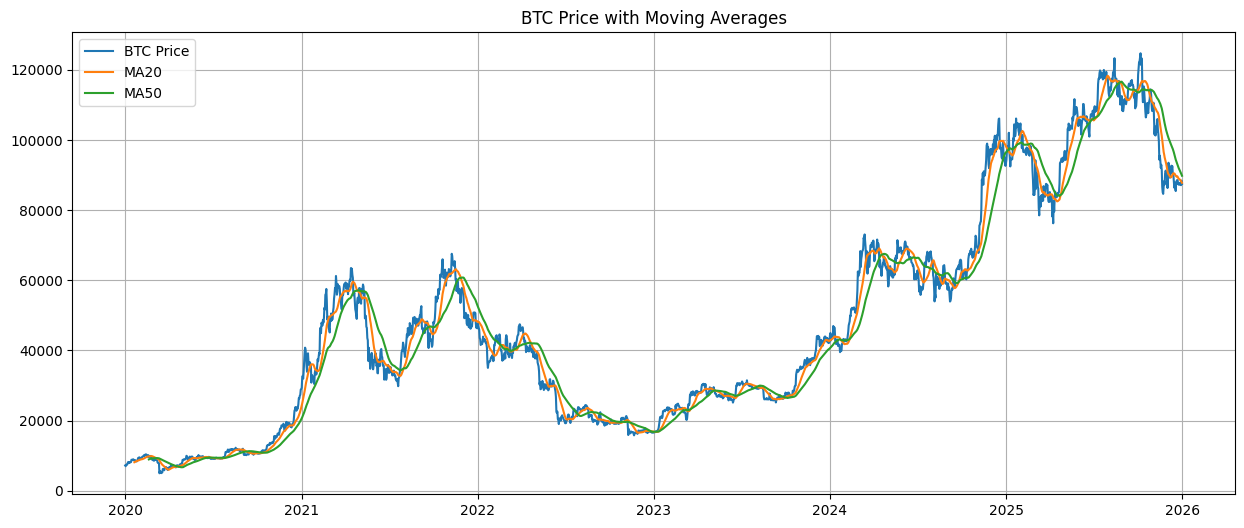

In [33]:
#Price & Moving Averages

plt.figure(figsize=(15,6))

plt.plot(
    btc.index,
    btc['Close'],
    label='BTC Price'
)

plt.plot(
    btc.index,
    btc['MA20'],
    label='MA20'
)

plt.plot(
    btc.index,
    btc['MA50'],
    label='MA50'
)

plt.title("BTC Price with Moving Averages")
plt.legend()
plt.grid(True)
plt.show()

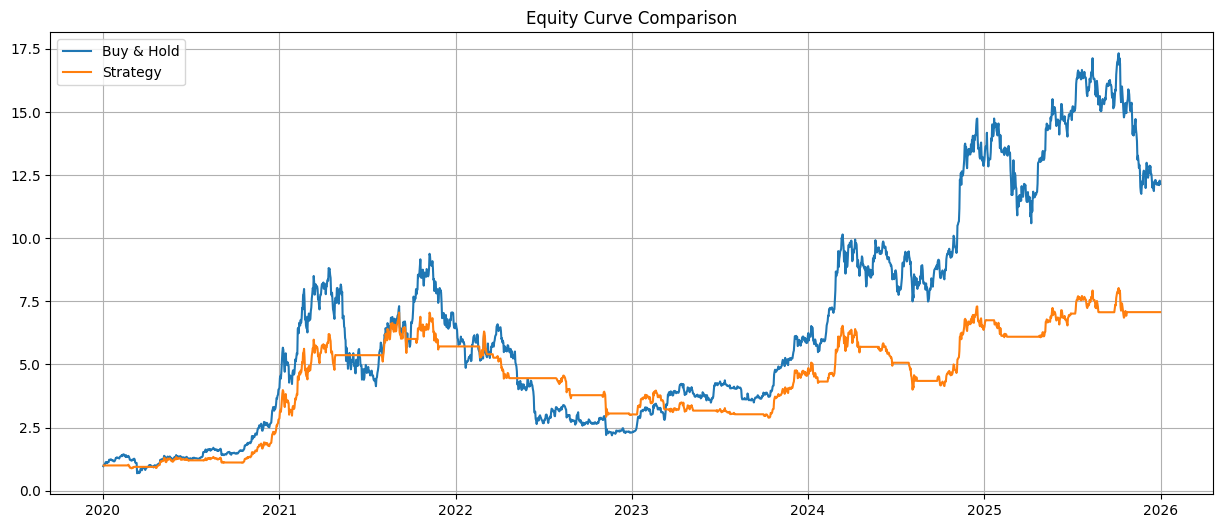

In [34]:
#Equity Curve

plt.figure(figsize=(15,6))

plt.plot(
    btc.index,
    btc['Market_Equity'],
    label='Buy & Hold'
)

plt.plot(
    btc.index,
    btc['Strategy_Equity'],
    label='Strategy'
)

plt.title("Equity Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

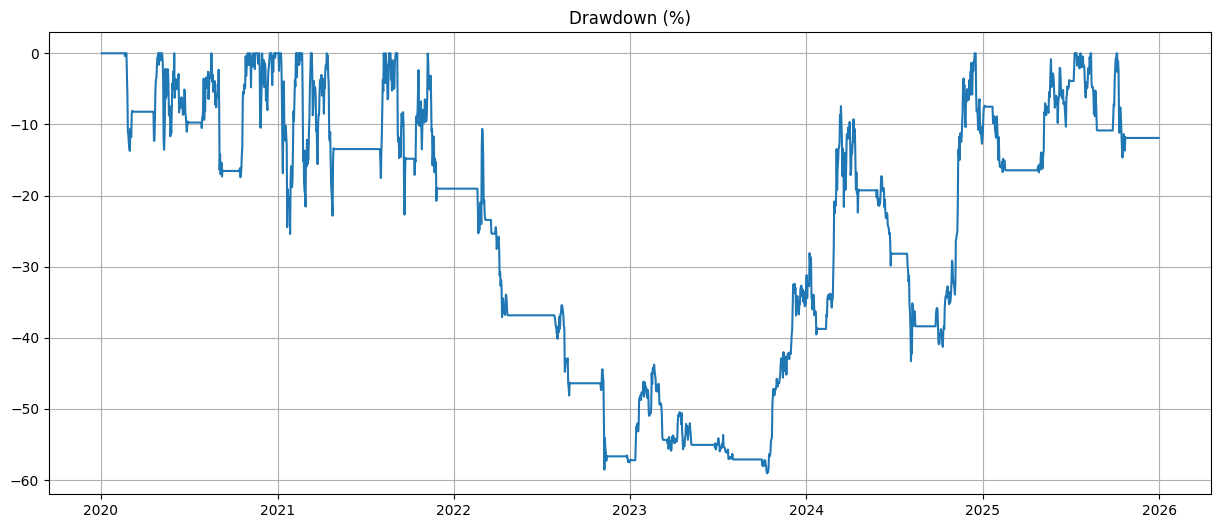

In [35]:
# Drawdown Chart

plt.figure(figsize=(15,6))

plt.plot(
    btc.index,
    drawdown * 100
)

plt.title("Drawdown (%)")
plt.grid(True)
plt.show()



Running Monte Carlo Simulation...


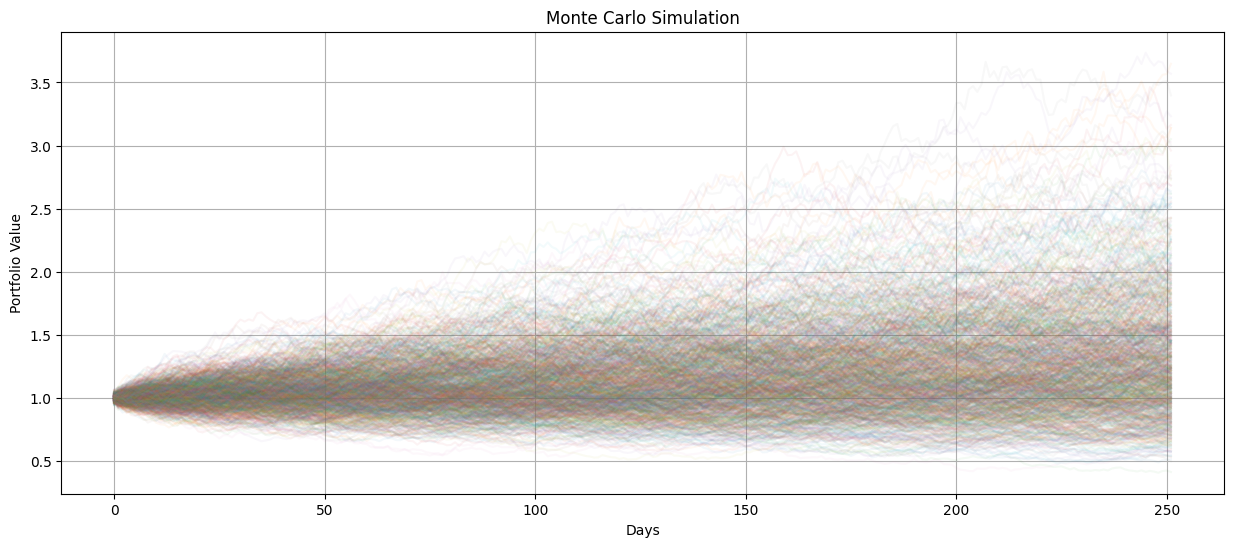

Simulation completed.


In [36]:
#Monte Carlo Simulation

print("\nRunning Monte Carlo Simulation...")

simulations = 1000
days = 252

results = np.zeros((days, simulations))

daily_mean = (
    btc['Strategy_Return']
    .dropna()
    .mean()
)

daily_std = (
    btc['Strategy_Return']
    .dropna()
    .std()
)

for i in range(simulations):

    simulated_returns = np.random.normal(
        daily_mean,
        daily_std,
        days
    )

    results[:, i] = (
        1 + simulated_returns
    ).cumprod()

plt.figure(figsize=(15,6))

plt.plot(
    results,
    alpha=0.05
)

plt.title("Monte Carlo Simulation")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.show()

print("Simulation completed.")